In [1]:
from GIT_vectors import GIT_vectors_func
from PCA_kmeans import PCA_func, Kernal_PCA_func
from anomaly_photo import anomaly_photo_func

/opt/anaconda3/envs/neuroshock/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/neuroshock/lib/python3.12/site-packages/open_clip/factory.py:388: UserWarning: These pretrained weights were trained with QuickGELU activation but the model config does not have that enabled. Consider using a model config with a "-quickgelu" suffix or enable with a flag.
  warnings.warn(


In [31]:
directory = '/Users/user/Desktop/НИС_2/Бутылки_165'
directory = '/Users/user/Desktop/ВКР_ИТМО/CAP_anomaly'

# directory = '/Users/user/Desktop/НИС_2/Рентген_305'

glob, result_vectors = GIT_vectors_func(directory)

top_farthest_points_idx = PCA_func(result_vectors, n_components=25, top_k = 10)

Обработано 43/43 изображений
Получено векторов: 43
Размерность вектора: 512


In [33]:
from sklearn.ensemble import IsolationForest
import numpy as np

def isolation_forest_outliers(result_vectors, contamination=0.05):
    iso_forest = IsolationForest(contamination=contamination, random_state=42)
    preds = iso_forest.fit_predict(result_vectors)  # -1 = выброс
    outlier_indices = np.where(preds == -1)[0]
    return outlier_indices  # можно взять top_k по score



top_farthest_points_idx = isolation_forest_outliers(result_vectors, contamination=0.05)

In [37]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
pca = PCA(n_components=25)

X_scaled = scaler.fit_transform(result_vectors)
result_vectors = pca.fit_transform(X_scaled)

In [38]:
from sklearn.svm import OneClassSVM
import numpy as np

def oneclasssvm_outliers(result_vectors, contamination=0.05):
    ocsvm = OneClassSVM(nu=contamination, kernel='rbf')
    preds = ocsvm.fit_predict(result_vectors)  # -1 = выброс, 1 = нормальный
    outlier_indices = np.where(preds == -1)[0]
    return outlier_indices

top_farthest_points_idx = oneclasssvm_outliers(result_vectors, contamination=0.06)

№_1   output_R3.png


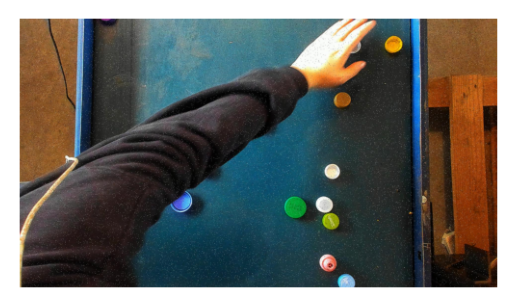

№_2   WIN_20210818_16_44_39_Pro_jpg.rf.6b4dca1bd877fabad9f0c7dcf8ff0291.jpg


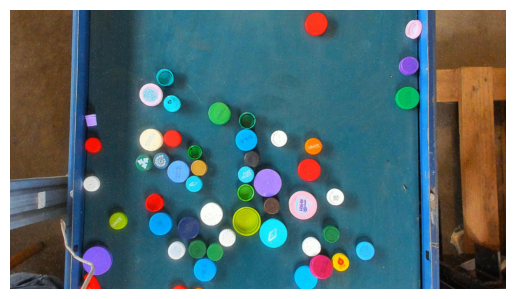

№_3   output_R2.png


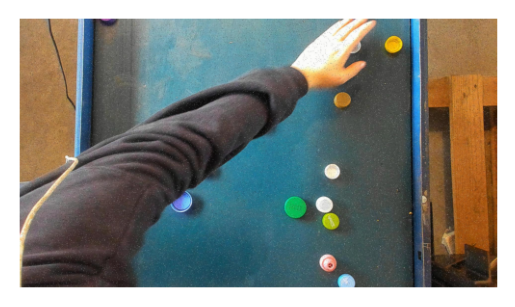

№_4   WIN_20210818_16_41_40_Pro_jpg.rf.e5f2ba512b64194ec92ed729956624ca.jpg


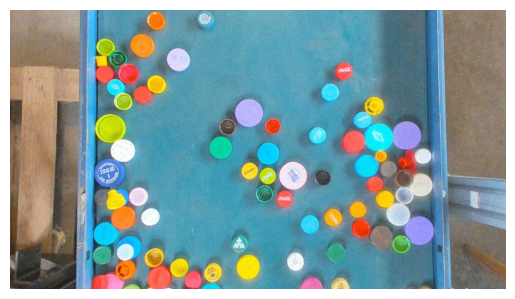

№_5   WIN_20210818_16_43_57_Pro_jpg.rf.805a87a8a3d985bc7ddc418e034df944.jpg


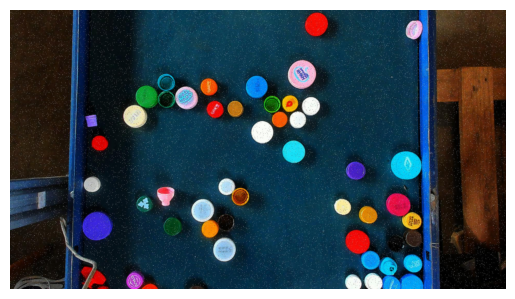

№_6   WIN_20210818_16_41_15_Pro_jpg.rf.af482f3ad8e7cfabcb4b6c5de32d3a0a.jpg


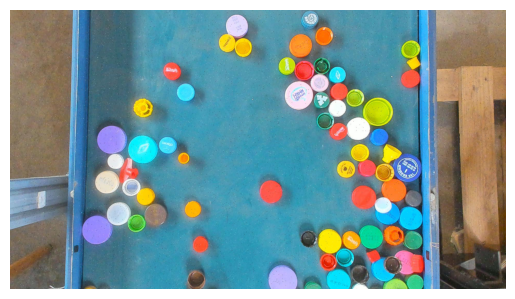

№_7   WIN_20210818_16_43_32_Pro_jpg.rf.ceb85346ed274d5b83be4e49bbf350a1.jpg


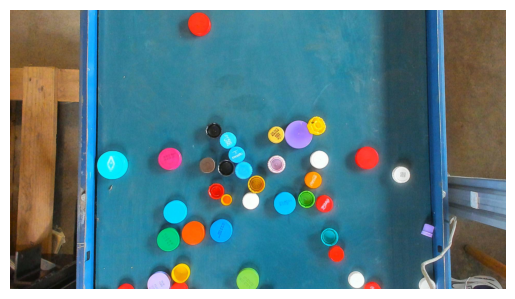

№_8   WIN_20210818_16_41_40_Pro_jpg.rf.2e6dc82e79ef6a5cf631946445625dc3.jpg


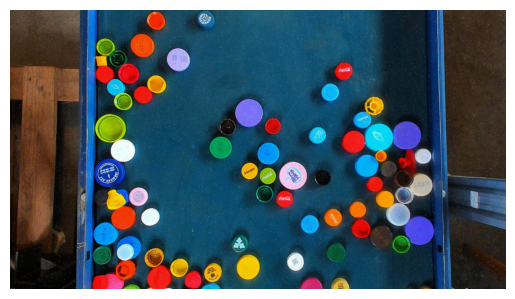

№_9   WIN_20210818_16_41_15_Pro_jpg.rf.833eaf1b2a49610fae0408ef551fd572.jpg


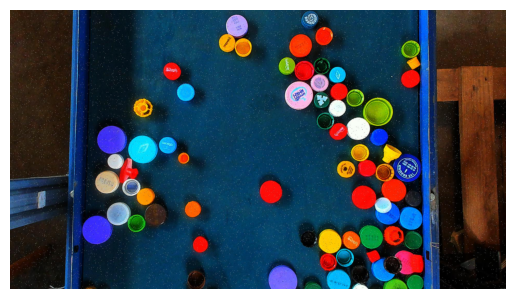

№_10   WIN_20210818_16_42_34_Pro_jpg.rf.881aa32fdaf63b8a94214fda84854878.jpg


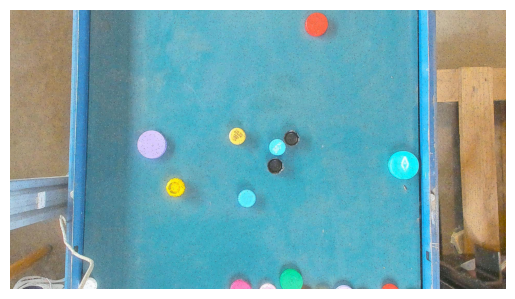

№_11   WIN_20210818_16_43_32_Pro_jpg.rf.8331c20730e8d678022d31eed67f3b2f.jpg


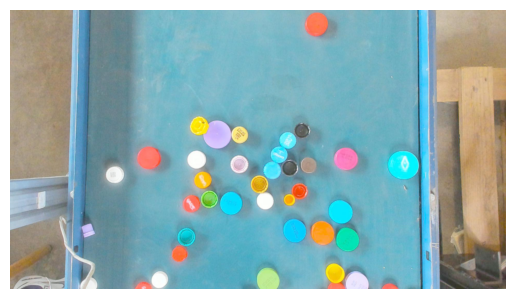

№_12   WIN_20210818_16_43_32_Pro_jpg.rf.0677d608d336ae2e480ff3d1ea7cc702.jpg


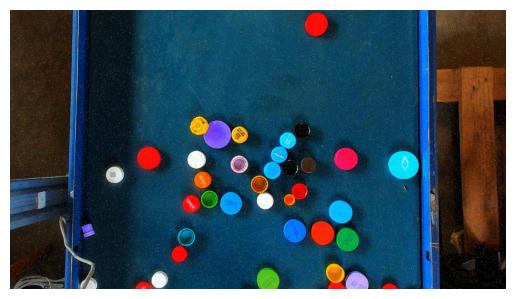

In [39]:
anomaly_photo_func(glob, top_farthest_points_idx)